In [6]:
import pandas as pd

# Load the 'Heart_disease' sheet from the Excel file
df = pd.read_excel('/content/heart_disease.xlsx', sheet_name='Heart_disease')

# Display the first 5 rows of the DataFrame
display(df.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [7]:
# Display basic information about the DataFrame
print("DataFrame Info:")
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [8]:
# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())


Missing values per column:


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,62


In [9]:
# Display descriptive statistics for numerical columns
print("\nDescriptive statistics for numerical columns:")
display(df.describe())


Descriptive statistics for numerical columns:


,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [10]:
# Display descriptive statistics for categorical columns
print("\nDescriptive statistics for categorical columns:")
display(df.describe(include='object'))


Descriptive statistics for categorical columns:


,sex,cp,restecg,exang,slope,thal
count,908,908,908,908,908,908
unique,2,4,3,4,3,3
top,Male,asymptomatic,normal,False,flat,normal
freq,718,495,542,516,453,386


In [22]:
# Impute missing values in 'oldpeak' with the median
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())

# Verify that missing values have been handled
print("Missing values after imputation for oldpeak:")
display(df.isnull().sum())

Missing values after imputation for oldpeak:


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,0


In [23]:
# Replace 0 values in 'trestbps' and 'chol' with NaN, as they are physiologically impossible.
df['trestbps'] = df['trestbps'].replace(0, pd.NA)
df['chol'] = df['chol'].replace(0, pd.NA)

# Impute these new missing values with the median
df['trestbps'] = df['trestbps'].fillna(df['trestbps'].median())
df['chol'] = df['chol'].fillna(df['chol'].median())

# Verify that missing values have been handled
print("Missing values after handling 0s in trestbps and chol:")
display(df.isnull().sum())

Missing values after handling 0s in trestbps and chol:


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,0


In [25]:
# Check unique values in 'exang' column before standardization
print("Unique values in 'exang' column before standardization:")
display(df['exang'].unique())

# Standardize 'exang' column to boolean values
df['exang'] = df['exang'].replace({'FALSE': False, 'TURE': True}).astype(bool)

# Verify the updated unique values in 'exang' column
print("Unique values in 'exang' column after standardization:")
display(df['exang'].unique())

Unique values in 'exang' column before standardization:


array([False, True, 'FALSE', 'TURE'], dtype=object)

Unique values in 'exang' column after standardization:


/tmp/ipykernel_1904/3575386585.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['exang'] = df['exang'].replace({'FALSE': False, 'TURE': True}).astype(bool)


array([False,  True])

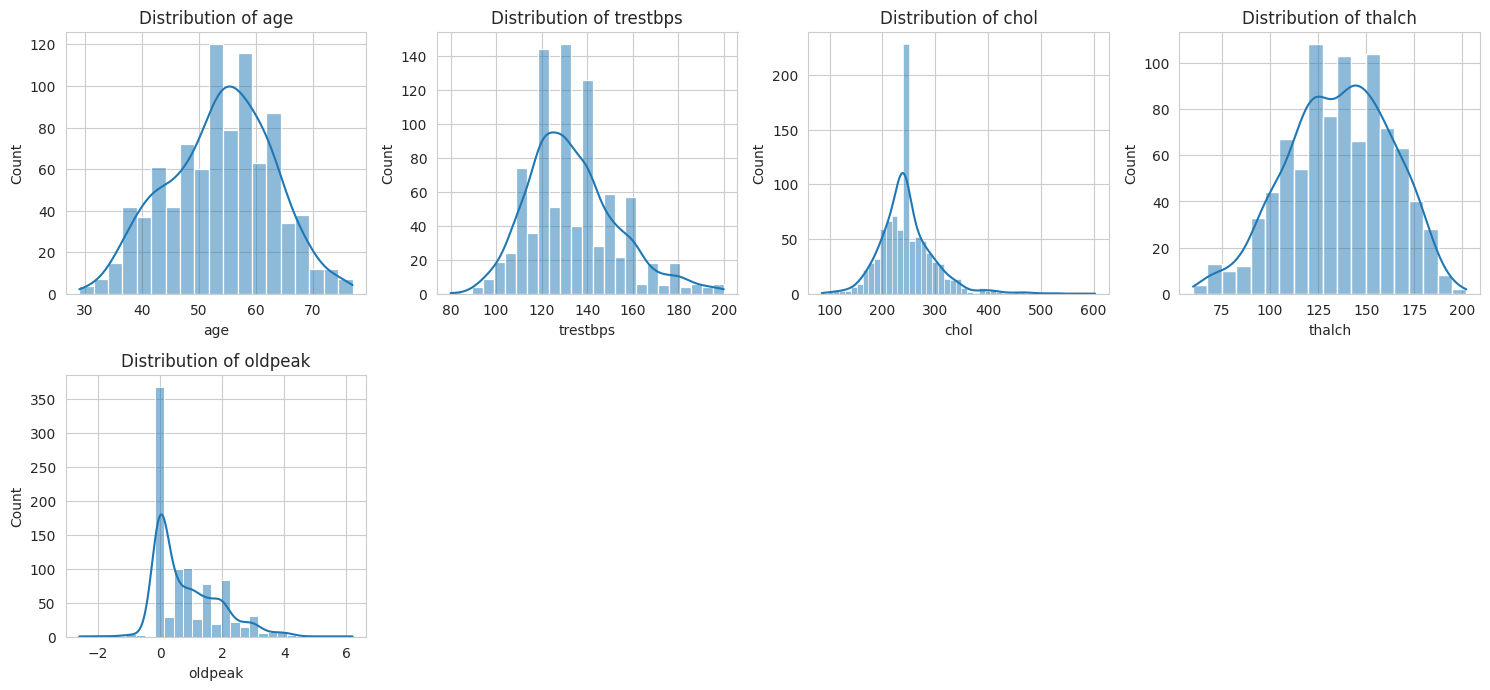

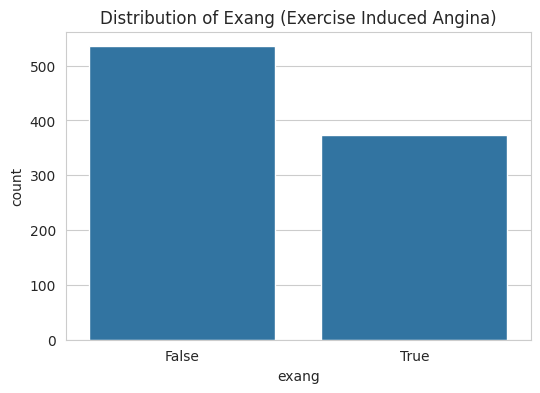

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Visualize distributions of numerical features
# Identify numerical columns (excluding the target variable 'num' for now)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'num' in numerical_cols:
    numerical_cols.remove('num')

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 4, i + 1) # Adjust subplot grid based on number of numerical columns
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
plt.show()

# Visualize the distribution of the 'exang' column (now standardized boolean)
plt.figure(figsize=(6, 4))
sns.countplot(x=df['exang'])
plt.title('Distribution of Exang (Exercise Induced Angina)')
plt.show()

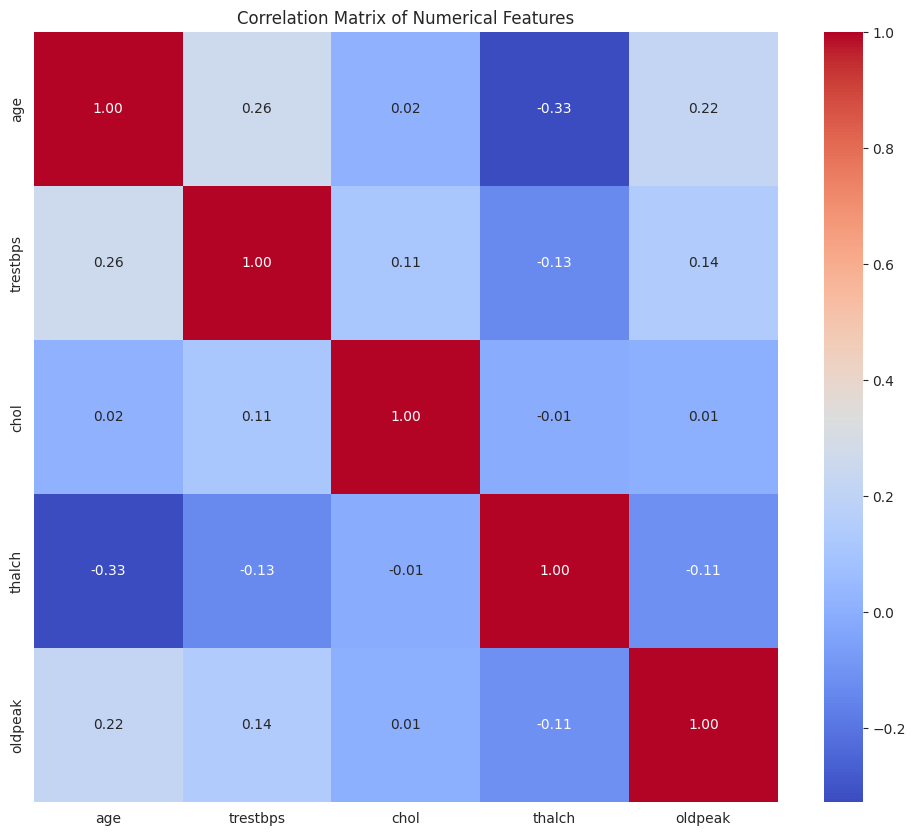

In [34]:
# Visualize the correlation matrix for numerical features
plt.figure(figsize=(12, 10))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [39]:
# Identify categorical columns to inspect (excluding 'exang' which is already handled)
categorical_cols_to_inspect = ['sex', 'cp', 'restecg', 'slope', 'thal']

print("\nUnique values for other categorical columns:")
for col in categorical_cols_to_inspect:
    print(f"Unique values in '{col}':")
    display(df[col].unique())
    print("\n")


Unique values for other categorical columns:
Unique values in 'sex':


array(['Male', 'Female'], dtype=object)



Unique values in 'cp':


array(['typical angina', 'atypical angina', 'asymptomatic', 'non-anginal'],
      dtype=object)



Unique values in 'restecg':


array(['lv hypertrophy', 'normal', 'st-t abnormality'], dtype=object)



Unique values in 'slope':


array(['downsloping', 'flat', 'upsloping'], dtype=object)



Unique values in 'thal':


array(['fixed defect', 'normal', 'reversable defect'], dtype=object)

In [40]:
# List of categorical columns to one-hot encode (excluding 'exang' as it's already boolean/binary)
categorical_cols_to_encode = ['sex', 'cp', 'restecg', 'slope', 'thal']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True, dtype=int)

print("DataFrame after One-Hot Encoding:")
display(df_encoded.head())
print("\nShape of DataFrame after encoding:", df_encoded.shape)

# Display new column names to verify encoding
print("\nNew columns created by one-hot encoding:")
encoded_columns = [col for col in df_encoded.columns if any(cat_col in col for cat_col in categorical_cols_to_encode)]
print(encoded_columns)

DataFrame after One-Hot Encoding:


,age,trestbps,chol,fbs,thalch,exang,oldpeak,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,True,150,False,2.3,0,1,0,0,1,0,0,0,0,0,0
1,41,135.0,203.0,False,132,False,0.0,0,1,1,0,0,1,0,1,0,0,0
2,57,140.0,192.0,False,148,False,0.4,0,1,0,0,0,1,0,1,0,0,0
3,52,118.0,186.0,False,190,False,0.0,0,1,0,0,1,0,0,1,0,0,0
4,57,110.0,201.0,False,126,True,1.5,0,1,0,0,0,1,0,1,0,0,0



Shape of DataFrame after encoding: (908, 18)

New columns created by one-hot encoding:
['thalch', 'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'restecg_normal', 'restecg_st-t abnormality', 'slope_flat', 'slope_upsloping', 'thal_normal', 'thal_reversable defect']


In [41]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_encoded.drop('num', axis=1) # Features are all columns except 'num'
y = df_encoded['num']             # Target is the 'num' column

# Split the data into training and testing sets
# Using a 80/20 split and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets successfully:
X_train shape: (726, 17)
y_train shape: (726,)
X_test shape: (182, 17)
y_test shape: (182,)


In [42]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42) # Using a random_state for reproducibility

# Train the model on the training data
dtc.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully!")

Decision Tree Classifier trained successfully!


Model Accuracy: 0.5330
Model Precision: 0.5272
Model Recall: 0.5330
Model F1-Score: 0.5293

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.72      0.72        89
           1       0.38      0.40      0.39        48
           2       0.42      0.45      0.43        22
           3       0.25      0.18      0.21        17
           4       0.17      0.17      0.17         6

    accuracy                           0.53       182
   macro avg       0.38      0.38      0.38       182
weighted avg       0.53      0.53      0.53       182



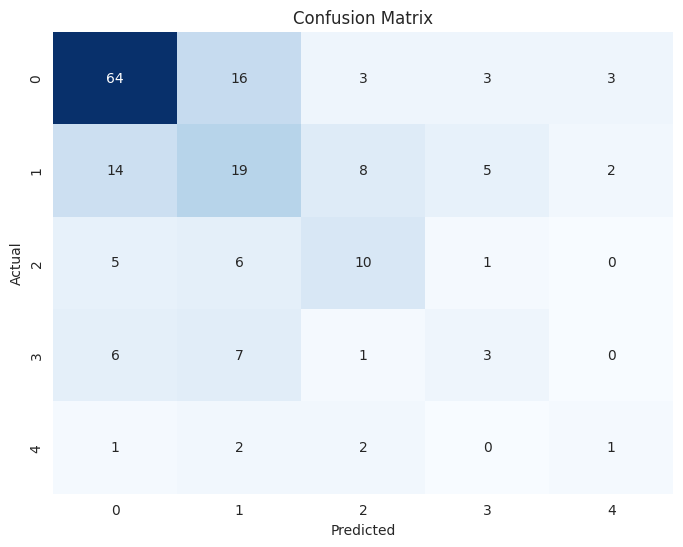

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Make predictions on the test set
y_pred = dtc.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Model Accuracy: {accuracy:.4f}")
print(f"Model Precision: {precision:.4f}")
print(f"Model Recall: {recall:.4f}")
print(f"Model F1-Score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=dtc.classes_, yticklabels=dtc.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [46]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("Best hyperparameters found:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

# Get the best model
best_dtc = grid_search.best_estimator_
print("Best Decision Tree Classifier obtained.")

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best hyperparameters found: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validation accuracy: 0.5675295229097779
Best Decision Tree Classifier obtained.


In [44]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("Best hyperparameters found:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

# Get the best model
best_dtc = grid_search.best_estimator_
print("Best Decision Tree Classifier obtained.")

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best hyperparameters found: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validation accuracy: 0.5675295229097779
Best Decision Tree Classifier obtained.



--- Tuned Decision Tree Classifier Performance ---
Tuned Model Accuracy: 0.5000
Tuned Model Precision: 0.4530
Tuned Model Recall: 0.5000
Tuned Model F1-Score: 0.4735

Classification Report for Tuned Model:
              precision    recall  f1-score   support

           0       0.74      0.76      0.75        89
           1       0.29      0.42      0.34        48
           2       0.00      0.00      0.00        22
           3       0.15      0.18      0.16        17
           4       0.00      0.00      0.00         6

    accuracy                           0.50       182
   macro avg       0.24      0.27      0.25       182
weighted avg       0.45      0.50      0.47       182



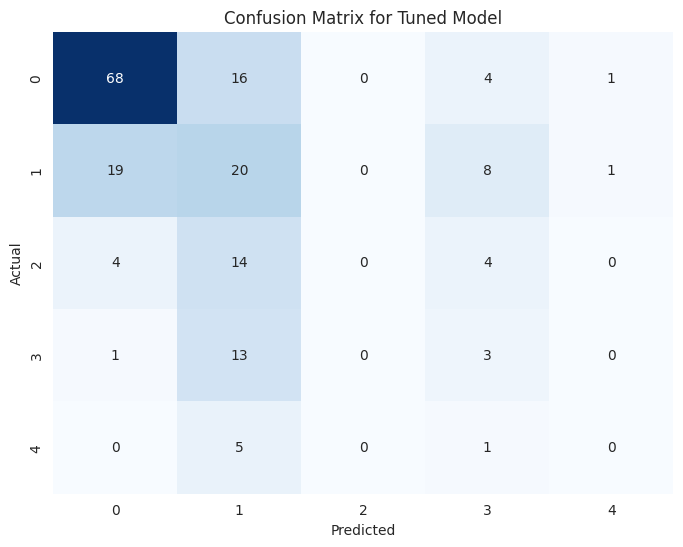

In [45]:
# Make predictions on the test set using the best model
y_pred_tuned = best_dtc.predict(X_test)

# Evaluate the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned, average='weighted', zero_division=0)
recall_tuned = recall_score(y_test, y_pred_tuned, average='weighted', zero_division=0)
f1_tuned = f1_score(y_test, y_pred_tuned, average='weighted', zero_division=0)

print("\n--- Tuned Decision Tree Classifier Performance ---")
print(f"Tuned Model Accuracy: {accuracy_tuned:.4f}")
print(f"Tuned Model Precision: {precision_tuned:.4f}")
print(f"Tuned Model Recall: {recall_tuned:.4f}")
print(f"Tuned Model F1-Score: {f1_tuned:.4f}")

print("\nClassification Report for Tuned Model:")
print(classification_report(y_test, y_pred_tuned, zero_division=0))

# Confusion Matrix for Tuned Model
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=best_dtc.classes_, yticklabels=best_dtc.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Tuned Model')
plt.show()

In [38]:
# Identify categorical columns to inspect (excluding 'exang' which is already handled)
categorical_cols_to_inspect = ['sex', 'cp', 'restecg', 'slope', 'thal']

print("\nUnique values for other categorical columns:")
for col in categorical_cols_to_inspect:
    print(f"Unique values in '{col}':")
    display(df[col].unique())
    print("\n")


Unique values for other categorical columns:
Unique values in 'sex':


array(['Male', 'Female'], dtype=object)



Unique values in 'cp':


array(['typical angina', 'atypical angina', 'asymptomatic', 'non-anginal'],
      dtype=object)



Unique values in 'restecg':


array(['lv hypertrophy', 'normal', 'st-t abnormality'], dtype=object)



Unique values in 'slope':


array(['downsloping', 'flat', 'upsloping'], dtype=object)



Unique values in 'thal':


array(['fixed defect', 'normal', 'reversable defect'], dtype=object)

In [37]:
# Identify categorical columns (excluding 'exang' which is already handled as boolean)
categorical_cols_to_check = ['sex', 'cp', 'restecg', 'slope', 'thal']

print("\nUnique values for other categorical columns:")
for col in categorical_cols_to_check:
    print(f"Unique values in '{col}':")
    display(df[col].unique())
    print("\n")


Unique values for other categorical columns:
Unique values in 'sex':


array(['Male', 'Female'], dtype=object)



Unique values in 'cp':


array(['typical angina', 'atypical angina', 'asymptomatic', 'non-anginal'],
      dtype=object)



Unique values in 'restecg':


array(['lv hypertrophy', 'normal', 'st-t abnormality'], dtype=object)



Unique values in 'slope':


array(['downsloping', 'flat', 'upsloping'], dtype=object)



Unique values in 'thal':


array(['fixed defect', 'normal', 'reversable defect'], dtype=object)

In [36]:
# Identify categorical columns (excluding 'exang' which is already handled as boolean)
categorical_cols_to_check = ['sex', 'cp', 'restecg', 'slope', 'thal']

print("\nUnique values for other categorical columns:")
for col in categorical_cols_to_check:
    print(f"Unique values in '{col}':")
    display(df[col].unique())
    print("\n")


Unique values for other categorical columns:
Unique values in 'sex':


array(['Male', 'Female'], dtype=object)



Unique values in 'cp':


array(['typical angina', 'atypical angina', 'asymptomatic', 'non-anginal'],
      dtype=object)



Unique values in 'restecg':


array(['lv hypertrophy', 'normal', 'st-t abnormality'], dtype=object)



Unique values in 'slope':


array(['downsloping', 'flat', 'upsloping'], dtype=object)



Unique values in 'thal':


array(['fixed defect', 'normal', 'reversable defect'], dtype=object)

In [35]:
# Identify categorical columns (excluding 'exang' which is already handled as boolean)
categorical_cols_to_check = ['sex', 'cp', 'restecg', 'slope', 'thal']

print("\nUnique values for other categorical columns:")
for col in categorical_cols_to_check:
    print(f"Unique values in '{col}':")
    display(df[col].unique())
    print("\n")


Unique values for other categorical columns:
Unique values in 'sex':


array(['Male', 'Female'], dtype=object)



Unique values in 'cp':


array(['typical angina', 'atypical angina', 'asymptomatic', 'non-anginal'],
      dtype=object)



Unique values in 'restecg':


array(['lv hypertrophy', 'normal', 'st-t abnormality'], dtype=object)



Unique values in 'slope':


array(['downsloping', 'flat', 'upsloping'], dtype=object)



Unique values in 'thal':


array(['fixed defect', 'normal', 'reversable defect'], dtype=object)

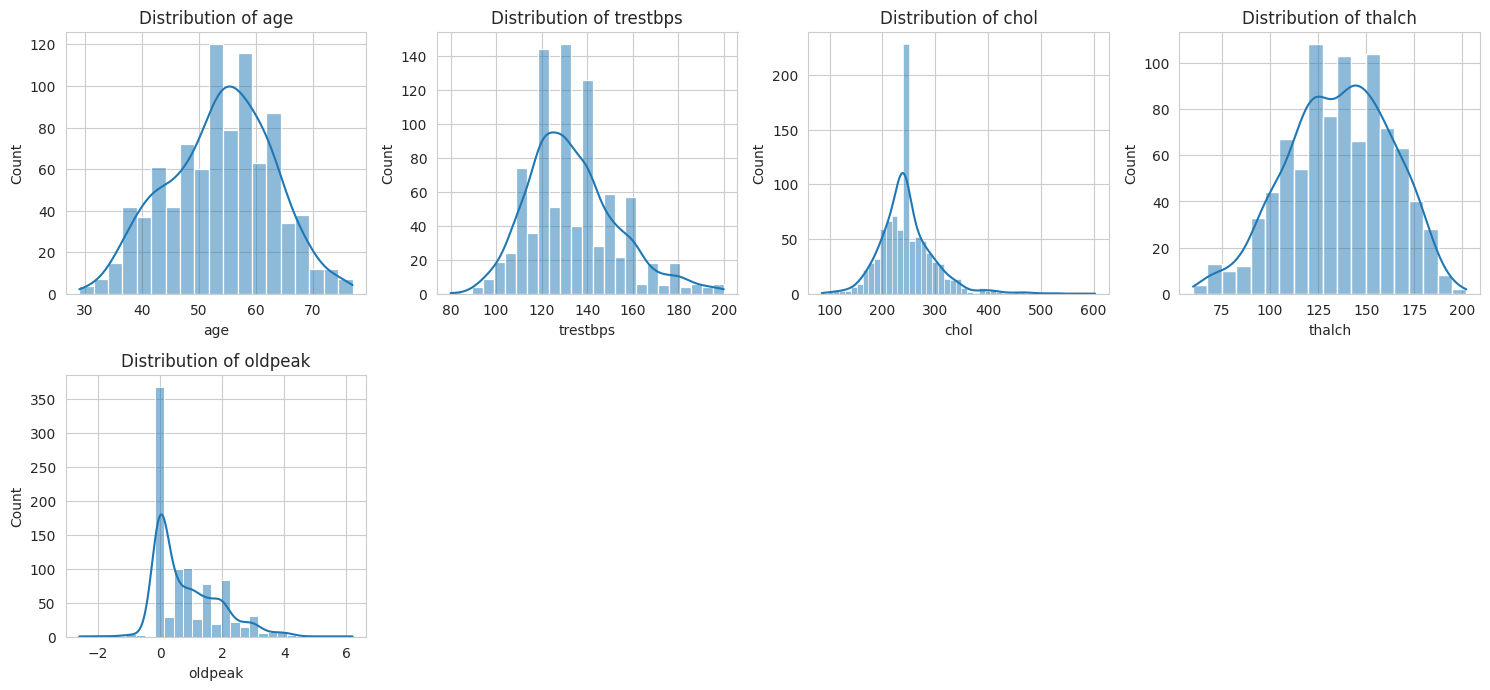

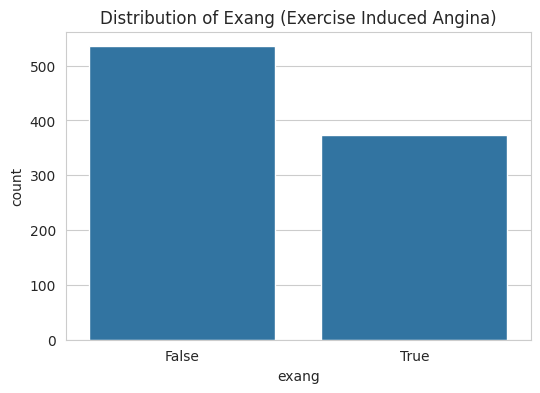

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Visualize distributions of numerical features
# Identify numerical columns (excluding the target variable 'num' for now)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'num' in numerical_cols:
    numerical_cols.remove('num')

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 4, i + 1) # Adjust subplot grid based on number of numerical columns
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
plt.show()

# Visualize the distribution of the 'exang' column (now standardized boolean)
plt.figure(figsize=(6, 4))
sns.countplot(x=df['exang'])
plt.title('Distribution of Exang (Exercise Induced Angina)')
plt.show()

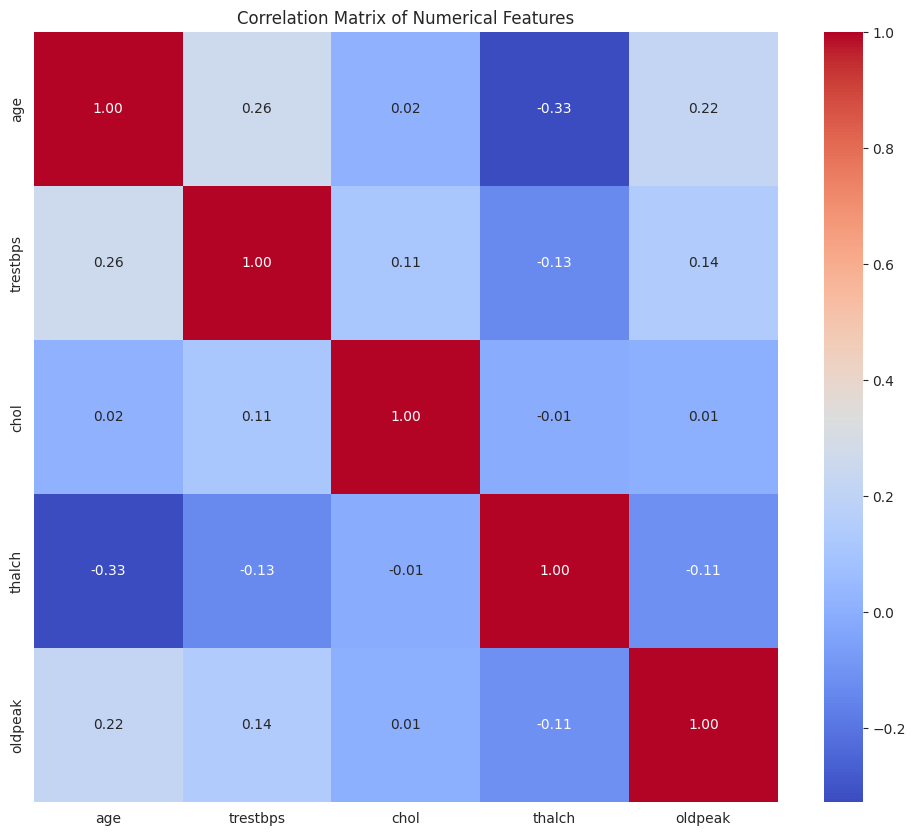

In [32]:
# Visualize the correlation matrix for numerical features
plt.figure(figsize=(12, 10))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

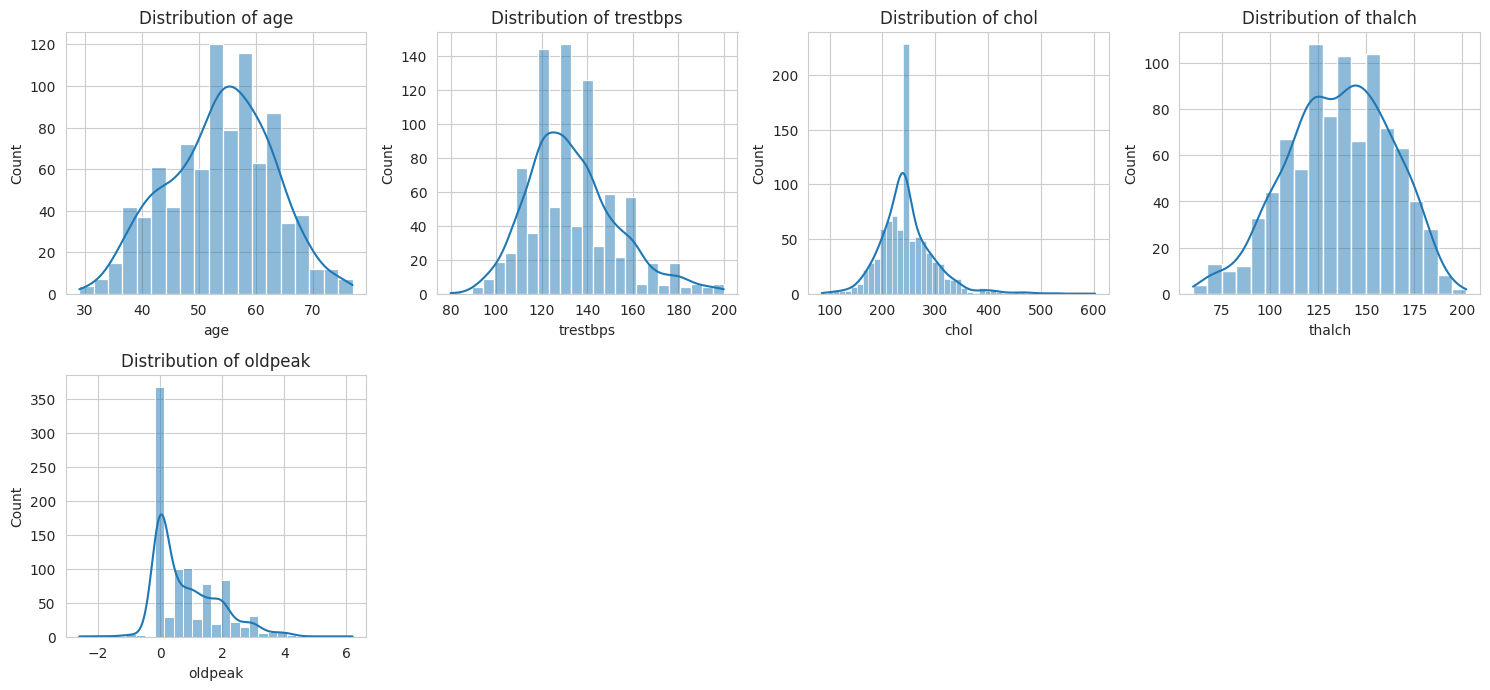

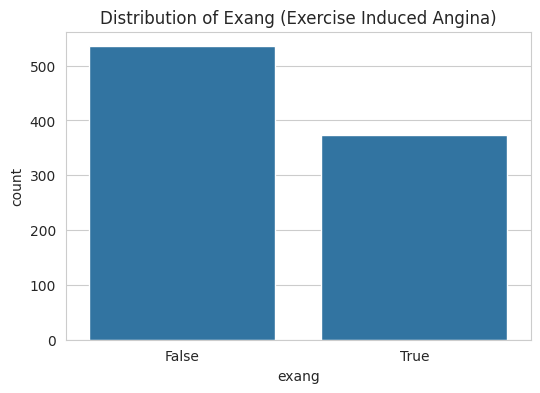

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Visualize distributions of numerical features
# Identify numerical columns (excluding the target variable 'num' for now)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'num' in numerical_cols:
    numerical_cols.remove('num')

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 4, i + 1) # Adjust subplot grid based on number of numerical columns
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
plt.show()

# Visualize the distribution of the 'exang' column (now standardized boolean)
plt.figure(figsize=(6, 4))
sns.countplot(x=df['exang'])
plt.title('Distribution of Exang (Exercise Induced Angina)')
plt.show()

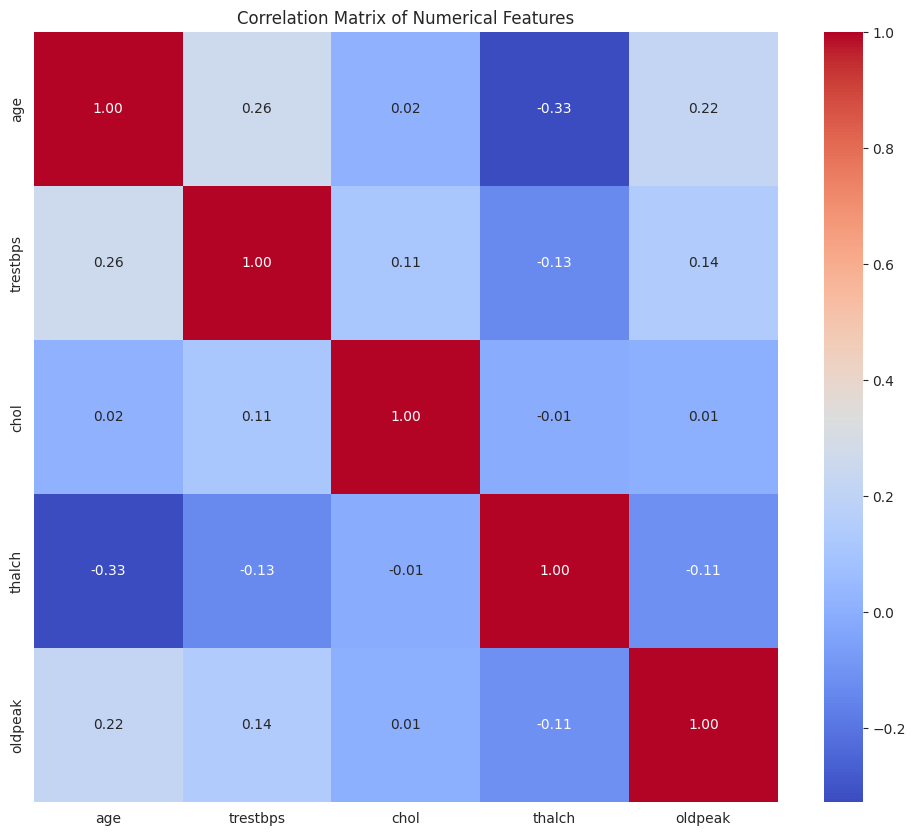

In [30]:
# Visualize the correlation matrix for numerical features
plt.figure(figsize=(12, 10))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

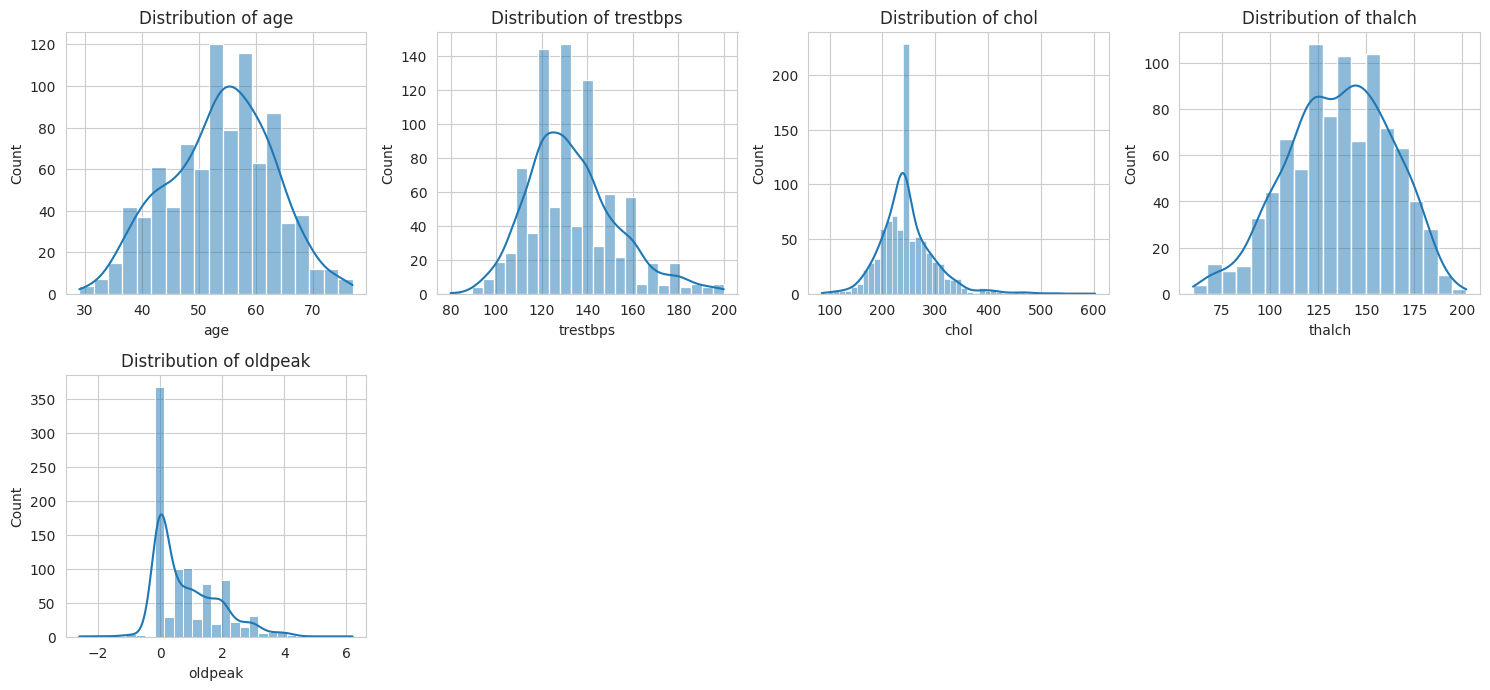

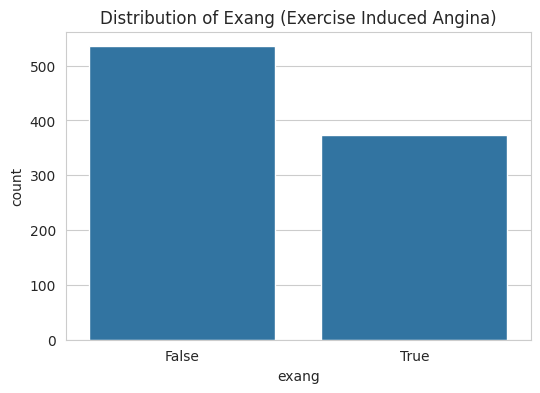

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Visualize distributions of numerical features
# Identify numerical columns (excluding the target variable 'num' for now)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'num' in numerical_cols:
    numerical_cols.remove('num')

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 4, i + 1) # Adjust subplot grid based on number of numerical columns
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
plt.show()

# Visualize the distribution of the 'exang' column (now standardized boolean)
plt.figure(figsize=(6, 4))
sns.countplot(x=df['exang'])
plt.title('Distribution of Exang (Exercise Induced Angina)')
plt.show()

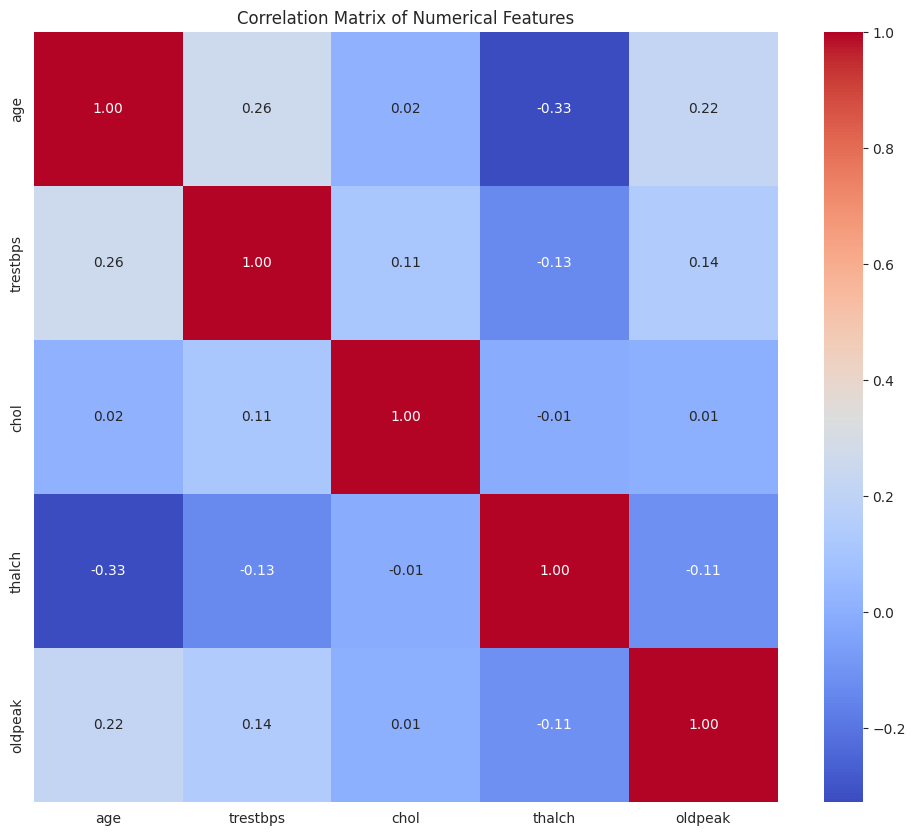

In [28]:
# Visualize the correlation matrix for numerical features
plt.figure(figsize=(12, 10))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [19]:
# Impute missing values in 'oldpeak' with the median
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())

# Verify that missing values have been handled
print("Missing values after imputation for oldpeak:")
display(df.isnull().sum())

Missing values after imputation for oldpeak:


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,0


In [20]:
# Replace 0 values in 'trestbps' and 'chol' with NaN, as they are physiologically impossible.
df['trestbps'] = df['trestbps'].replace(0, pd.NA)
df['chol'] = df['chol'].replace(0, pd.NA)

# Impute these new missing values with the median
df['trestbps'] = df['trestbps'].fillna(df['trestbps'].median())
df['chol'] = df['chol'].fillna(df['chol'].median())

# Verify that missing values have been handled
print("Missing values after handling 0s in trestbps and chol:")
display(df.isnull().sum())

Missing values after handling 0s in trestbps and chol:


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,0


In [17]:
# Impute missing values in 'oldpeak' with the median
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())

# Verify that missing values have been handled
print("Missing values after imputation:")
display(df.isnull().sum())

Missing values after imputation:


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,0


In [18]:
# Replace 0 values in 'trestbps' and 'chol' with NaN, as they are physiologically impossible.
df['trestbps'] = df['trestbps'].replace(0, pd.NA)
df['chol'] = df['chol'].replace(0, pd.NA)

# Impute these new missing values with the median
df['trestbps'] = df['trestbps'].fillna(df['trestbps'].median())
df['chol'] = df['chol'].fillna(df['chol'].median())

# Verify that missing values have been handled
print("Missing values after handling 0s in trestbps and chol:")
display(df.isnull().sum())

Missing values after handling 0s in trestbps and chol:


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,0


In [26]:
# Check unique values in 'exang' to understand its categories (before standardization)
print("Unique values in 'exang' column before standardization:")
display(df['exang'].unique())

# Standardize 'exang' column to boolean values
df['exang'] = df['exang'].replace({'FALSE': False, 'TURE': True}).astype(bool)

# Verify the updated unique values in 'exang'
print("Unique values in 'exang' column after standardization:")
display(df['exang'].unique())

Unique values in 'exang' column before standardization:


array([False,  True])

Unique values in 'exang' column after standardization:


array([False,  True])

In [15]:
# Impute missing values in 'oldpeak' with the median
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())

# Verify that missing values have been handled
print("Missing values after imputation:")
display(df.isnull().sum())

Missing values after imputation:


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,0


In [16]:
# Replace 0 values in 'trestbps' and 'chol' with NaN, as they are physiologically impossible.
df['trestbps'] = df['trestbps'].replace(0, pd.NA)
df['chol'] = df['chol'].replace(0, pd.NA)

# Impute these new missing values with the median
df['trestbps'] = df['trestbps'].fillna(df['trestbps'].median())
df['chol'] = df['chol'].fillna(df['chol'].median())

# Verify that missing values have been handled
print("Missing values after handling 0s in trestbps and chol:")
display(df.isnull().sum())

Missing values after handling 0s in trestbps and chol:


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,0
